# Sequential CAV Debiasing

Pipeline dla jednego konceptu:
1. Wyciąga aktywacje CLIP warstwa po warstwie
2. Na każdej warstwie wyznacza CAV trzema metodami (diff_means, lr, pclarc)
3. Mierzy accuracy CAV (train i test)
4. Każda kolejna warstwa otrzymuje aktywacje już zdebiesowane na wszystkich poprzednich
5. Zapisuje aktywacje przed/po debiasingu (`layer_XX.parquet`) i CAV + metryki (`cavs.csv`)

**Zmień tylko `CONCEPT` - reszta wynika automatycznie.**

In [16]:
import os, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image
from dotenv import load_dotenv
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from transformers import AutoModel, AutoImageProcessor
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

warnings.filterwarnings('ignore')
load_dotenv()

True

In [ ]:
CONCEPT        = 'eyeglasses'


NUM_LAYERS     = 24
GPU_BATCH_SIZE = 64
NUM_WORKERS    = 0          # Windows + Jupyter: spawn-based multiprocessing breaks workers
MODEL_ID       = 'openai/clip-vit-large-patch14'
PARQUET_COMPRESSION = 'snappy'
METHODS        = ['diff_means', 'lr', 'pclarc']

In [18]:
ROOT = Path.cwd()
for _ in range(6):
    if (ROOT / 'pyproject.toml').exists():
        break
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

METADATA_PATH = ROOT / 'data' / f'metadata_{CONCEPT}.csv'
IMAGES_DIR    = ROOT / 'data' / f'images_{CONCEPT}'
DATA_OUT      = ROOT / 'data' / 'checkpoint2_data' / CONCEPT

if not METADATA_PATH.exists():
    raise FileNotFoundError(
        f"Brak pliku metadanych: {METADATA_PATH}\n"
        f"Uruchom najpierw scripts/download_data.ipynb z CONCEPT='{CONCEPT}'"
    )
if not IMAGES_DIR.exists():
    raise FileNotFoundError(
        f"Brak folderu ze zdjęciami: {IMAGES_DIR}\n"
        f"Uruchom najpierw scripts/download_data.ipynb z BALANCE_CONCEPT='{CONCEPT}'"
    )

for m in METHODS:
    (DATA_OUT / m / 'activations').mkdir(parents=True, exist_ok=True)

print(f'Koncept  : {CONCEPT}')
print(f'ROOT     : {ROOT}')
print(f'Data out : {DATA_OUT}')

Koncept  : eyeglasses
ROOT     : e:\Do gita\WB2
Data out : e:\Do gita\WB2\data\checkpoint2_data\eyeglasses


In [ ]:
df_meta = pd.read_csv(METADATA_PATH)

if CONCEPT not in df_meta.columns:
    raise ValueError(
        f"Brak kolumny '{CONCEPT}' w {METADATA_PATH}.\n"
        f"Dostępne kolumny: {list(df_meta.columns)}"
    )

df_train = df_meta[df_meta['split'] == 'train'].reset_index(drop=True)
df_test  = df_meta[df_meta['split'] == 'test'].reset_index(drop=True)

print(f'Train : {len(df_train)} próbek | {df_train[CONCEPT].mean():.1%} pos')
print(f'Test  : {len(df_test)}  próbek | {df_test[CONCEPT].mean():.1%} pos')

Train : 150 próbek | 40.0% pos
Test  : 50  próbek | 50.0% pos


In [42]:
HF_TOKEN = os.getenv('HF_TOKEN')
device   = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype    = torch.bfloat16 if device == 'cuda' else torch.float32

processor = AutoImageProcessor.from_pretrained(MODEL_ID, token=HF_TOKEN)
model = AutoModel.from_pretrained(
    MODEL_ID,
    dtype=dtype,
    low_cpu_mem_usage=True,
    token=HF_TOKEN,
).to(device).eval()

print(f'Model: {MODEL_ID} | device: {device} | dtype: {dtype}')


class CelebADataset(Dataset):
    def __init__(self, df, images_dir, processor):
        self.df = df.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.processor  = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.images_dir / row['filename']).convert('RGB')
        px  = self.processor(images=img, return_tensors='pt').pixel_values.squeeze(0)
        return px, int(row[CONCEPT])


def make_loader(df):
    return DataLoader(
        CelebADataset(df, IMAGES_DIR, processor),
        batch_size=GPU_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(device == 'cuda'),
        persistent_workers=(NUM_WORKERS > 0),
    )

loader_train = make_loader(df_train)
loader_test  = make_loader(df_test)

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

Model: openai/clip-vit-large-patch14 | device: cuda | dtype: torch.bfloat16


In [43]:
class _StopForward(Exception):
    """Rzucana z hooka na docelowej warstwie - przerywa forward pass."""
    pass


def _make_debias_hook(cav_np, method, target_val=None):
    """Hook modyfikujący token CLS na wyjściu warstwy."""
    cav = torch.from_numpy(cav_np).float()

    def hook(module, input, output):
        is_tuple = isinstance(output, tuple)
        hidden   = output[0] if is_tuple else output   # (B, seq, D)

        cls   = hidden[:, 0, :].float()                # (B, D)
        cav_d = cav.to(cls.device)
        proj  = cls @ cav_d                            # (B,)

        if method in ('diff_means', 'lr'):
            # rzut ortogonalny: usuń komponentę wzdłuż CAV
            cls_new = cls - proj.unsqueeze(1) * cav_d
        else:  # pclarc
            # przesuń do poziomu projekcji klasy negatywnej
            t       = torch.tensor(target_val, dtype=torch.float32, device=cls.device)
            cls_new = cls + (t - proj).unsqueeze(1) * cav_d

        h_new = hidden.clone()
        h_new[:, 0, :] = cls_new.to(hidden.dtype)
        return (h_new,) + output[1:] if is_tuple else h_new

    return hook


def run_to_layer(loader, target_layer, past_cavs, method):
    """
    Przepuszcza wszystkie obrazy przez CLIP zatrzymując się na `target_layer`.
    Na warstwach < target_layer aplikuje debiasing (past_cavs).

    past_cavs: list[(cav_np, target_val | None)]  - po jednym na każdą poprzednią warstwę
    Zwraca: (X: float32 array (N, D), y: int array (N,))
    """
    encoder_layers = model.vision_model.encoder.layers
    handles = []

    # Hooki debiasujące na warstwach 0 .. target_layer-1
    for k, (cav_np, t_val) in enumerate(past_cavs):
        h = encoder_layers[k].register_forward_hook(
            _make_debias_hook(cav_np, method, t_val)
        )
        handles.append(h)

    # Hook przechwytujący + zatrzymujący na target_layer
    _buf = []
    def _capture(module, input, output):
        hidden = output[0] if isinstance(output, tuple) else output
        _buf.append(hidden[:, 0, :].detach().float().cpu().numpy())
        raise _StopForward()

    handles.append(encoder_layers[target_layer].register_forward_hook(_capture))

    X_all, y_all = [], []
    try:
        with torch.no_grad():
            for pixels, labels in loader:
                _buf.clear()
                try:
                    model.get_image_features(pixel_values=pixels.to(device, dtype=dtype))
                except _StopForward:
                    pass
                if _buf:
                    X_all.append(_buf[0])
                y_all.extend(labels.tolist())
    finally:
        for h in handles:
            h.remove()

    return np.concatenate(X_all, axis=0), np.array(y_all, dtype=int)

In [ ]:
def compute_diff_means(X_tr, y_tr):
    """CAV = znormalizowana różnica średnich klas."""
    X = X_tr.astype(np.float64)
    diff = X[y_tr == 1].mean(axis=0) - X[y_tr == 0].mean(axis=0)
    n = np.linalg.norm(diff)
    return (diff / n).astype(np.float32) if n > 1e-10 else None


def compute_lr_cav(X_tr, y_tr):
    """
    CAV z regresji logistycznej trenowanej na skalowanych aktywacjach.
    Wagi transformowane z powrotem do przestrzeni oryginalnej (bez skalowania)
    - dzięki temu hook działa na surowych aktywacjach.
    Zwraca: (cav_np, scaler, lr_model)
    """
    sc = StandardScaler()
    Xs = sc.fit_transform(X_tr.astype(np.float64))
    lr = LogisticRegression(C=0.01, solver='lbfgs', max_iter=2000, random_state=42)
    lr.fit(Xs, y_tr)

    # w_scaled @ (x - mean)/std = (w_scaled/std) @ x + const
    # → kierunek w przestrzeni oryginalnej = w_scaled / scale
    w = lr.coef_[0] / sc.scale_
    n = np.linalg.norm(w)
    if n < 1e-10:
        return None, sc, lr
    return (w / n).astype(np.float32), sc, lr


def cav_accuracy_dm(X, y, cav):
    """Accuracy przez rzut na CAV i próg w połowie drogi między średnimi klas."""
    proj = X.astype(np.float64) @ cav.astype(np.float64)
    t    = (proj[y == 1].mean() + proj[y == 0].mean()) / 2
    acc  = accuracy_score(y, (proj > t).astype(int))
    return max(acc, 1.0 - acc)   # obsługa odwróconego znaku


def cav_accuracy_lr(X, y, sc, lr_model):
    """Accuracy regresji logistycznej na skalowanych aktywacjach."""
    return lr_model.score(sc.transform(X.astype(np.float64)), y)


def apply_orthogonal(X, cav):
    """Projekt ortogonalny: usuwa komponentę wzdłuż CAV."""
    X64 = X.astype(np.float64)
    c64 = cav.astype(np.float64)
    return (X64 - np.outer(X64 @ c64, c64)).astype(np.float32)


def apply_pclarc(X, cav, target_val):
    """PCLARC: przesuwa próbki do poziomu projekcji klasy negatywnej."""
    X64 = X.astype(np.float64)
    c64 = cav.astype(np.float64)
    return (X64 + np.outer(target_val - X64 @ c64, c64)).astype(np.float32)

In [45]:
def save_layer_parquet(X_tr_pre, X_tr_post, y_tr,
                       X_te_pre, X_te_post, y_te,
                       method, layer_idx):
    D = X_tr_pre.shape[1]
    pre_cols  = [str(i)    for i in range(D)]   # '0'..'1023'
    post_cols = [f'd_{i}'  for i in range(D)]   # 'd_0'..'d_1023'

    def to_df(X_pre, X_post, y, split):
        df = pd.DataFrame(X_pre.astype(np.float32),  columns=pre_cols)
        dp = pd.DataFrame(X_post.astype(np.float32), columns=post_cols)
        dp[CONCEPT] = y.astype(int)
        dp['split'] = split
        return pd.concat([df, dp], axis=1)

    out = pd.concat([
        to_df(X_tr_pre, X_tr_post, y_tr, 'train'),
        to_df(X_te_pre, X_te_post, y_te, 'test'),
    ], ignore_index=True)

    path = DATA_OUT / method / 'activations' / f'layer_{layer_idx:02d}.parquet'
    out.to_parquet(path, compression=PARQUET_COMPRESSION, index=False)
    return path

In [46]:
methods_to_run = [m for m in METHODS if not (DATA_OUT / m / 'cavs.csv').exists()]

if not methods_to_run:
    print("Wszystkie metody już obliczone - pomijam pipeline, przechodzę do wizualizacji.")
else:
    print(f"Do obliczenia: {methods_to_run}")

    # accumulated state per method: list[(cav_np, target_val | None)]
    state       = {m: [] for m in methods_to_run}
    cav_records = {m: [] for m in methods_to_run}

    for layer_idx in tqdm(range(NUM_LAYERS), desc='Warstwy'):

        for method in tqdm(methods_to_run, desc=f'L{layer_idx:02d}', leave=False):
            past = state[method]

            # --- forward pass do bieżącej warstwy ---
            X_tr, y_tr = run_to_layer(loader_train, layer_idx, past, method)
            X_te, y_te = run_to_layer(loader_test,  layer_idx, past, method)

            # --- wyznaczenie CAV ---
            sc = lr_m = None
            if method == 'lr':
                cav, sc, lr_m = compute_lr_cav(X_tr, y_tr)
            else:  # diff_means i pclarc używają tego samego kierunku
                cav = compute_diff_means(X_tr, y_tr)

            if cav is None:
                print(f'  L{layer_idx:02d} {method}: CAV=None, pomijam')
                continue

            # --- accuracy ---
            if method == 'lr':
                acc_tr = cav_accuracy_lr(X_tr, y_tr, sc, lr_m)
                acc_te = cav_accuracy_lr(X_te, y_te, sc, lr_m)
            else:
                acc_tr = cav_accuracy_dm(X_tr, y_tr, cav)
                acc_te = cav_accuracy_dm(X_te, y_te, cav)

            # --- aktywacje po debiasingu ---
            if method == 'pclarc':
                # target = poziom projekcji klasy negatywnej (trenig)
                target_val = float(
                    (X_tr.astype(np.float64)[y_tr == 0] @ cav.astype(np.float64)).mean()
                )
                X_tr_post = apply_pclarc(X_tr, cav, target_val)
                X_te_post = apply_pclarc(X_te, cav, target_val)
            else:
                target_val = None
                X_tr_post  = apply_orthogonal(X_tr, cav)
                X_te_post  = apply_orthogonal(X_te, cav)

            # --- zapis ---
            save_layer_parquet(
                X_tr, X_tr_post, y_tr,
                X_te, X_te_post, y_te,
                method, layer_idx,
            )

            # --- aktualizacja stanu ---
            state[method].append((cav, target_val))

            cav_records[method].append({
                'layer_id':  layer_idx,
                'train_acc': acc_tr,
                'test_acc':  acc_te,
                'target_val': target_val,
                **{f'cav_{i}': float(cav[i]) for i in range(len(cav))},
            })

    # --- zapis cavs.csv ---
    for method in methods_to_run:
        if cav_records[method]:
            df_cav = pd.DataFrame(cav_records[method])
            path   = DATA_OUT / method / 'cavs.csv'
            df_cav.to_csv(path, index=False)
            print(f'Zapisano: {path}')

    print('\nPipeline zakończony.')

Do obliczenia: ['diff_means', 'lr', 'pclarc']


Warstwy:   0%|          | 0/24 [00:00<?, ?it/s]

L00:   0%|          | 0/3 [00:00<?, ?it/s]

L01:   0%|          | 0/3 [00:00<?, ?it/s]

L02:   0%|          | 0/3 [00:00<?, ?it/s]

...

L20:   0%|          | 0/3 [00:00<?, ?it/s]

L21:   0%|          | 0/3 [00:00<?, ?it/s]

L22:   0%|          | 0/3 [00:00<?, ?it/s]

L23:   0%|          | 0/3 [00:00<?, ?it/s]

Zapisano: e:\Do gita\WB2\data\checkpoint2_data\eyeglasses\diff_means\cavs.csv
Zapisano: e:\Do gita\WB2\data\checkpoint2_data\eyeglasses\lr\cavs.csv
Zapisano: e:\Do gita\WB2\data\checkpoint2_data\eyeglasses\pclarc\cavs.csv

Pipeline zakończony.


## Wizualizacja: accuracy CAV per warstwa

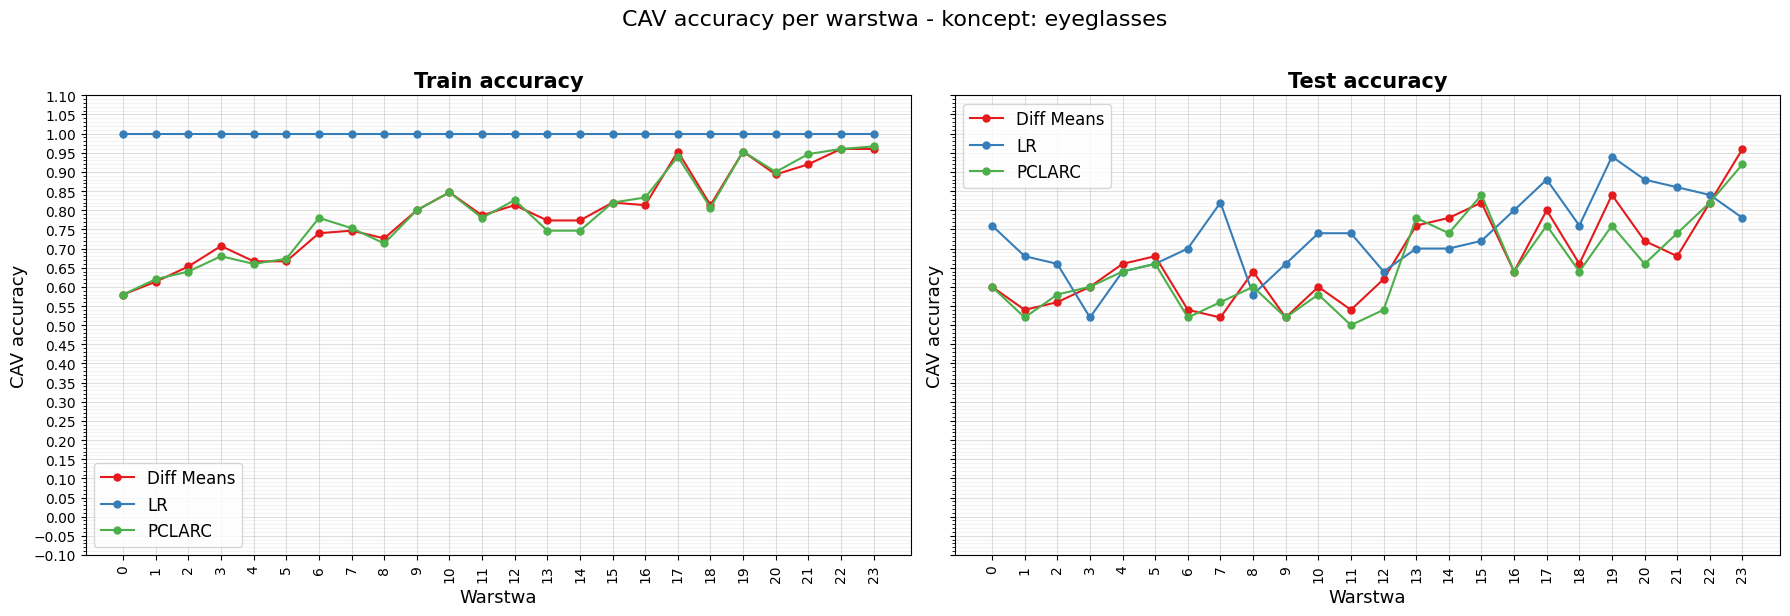

Zapisano: e:\Do gita\WB2\data\checkpoint2_data\eyeglasses\cav_accuracy_per_layer.png


In [51]:
# Wczytaj wyniki wszystkich metod
dfs = {}
for m in METHODS:
    p = DATA_OUT / m / 'cavs.csv'
    if not p.exists():
        print(f'Brak wyników dla {m} ({p})')
        continue
    dfs[m] = pd.read_csv(p)[['layer_id', 'train_acc', 'test_acc']]

assert dfs, 'Brak jakichkolwiek wyników - uruchom pipeline powyżej.'

COLORS = {'diff_means': '#e41a1c', 'lr': '#377eb8', 'pclarc': '#4daf4a'}
LABELS = {'diff_means': 'Diff Means', 'lr': 'LR', 'pclarc': 'PCLARC'}

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for method, df in dfs.items():
    color = COLORS[method]
    label = LABELS[method]
    layers = df['layer_id']

    for ax, col, title in zip(
        axes,
        ['train_acc', 'test_acc'],
        ['Train accuracy', 'Test accuracy'],
    ):
        ax.plot(layers, df[col], marker='o', ms=5, color=color, label=label)

for ax, title in zip(axes, ['Train accuracy', 'Test accuracy']):
    ax.set_xlabel('Warstwa', fontsize=13)
    ax.set_ylabel('CAV accuracy', fontsize=13)
    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.set_xticks(range(NUM_LAYERS))
    ax.set_xticklabels([str(i) for i in range(NUM_LAYERS)], rotation=90)
    ax.set_ylim(-0.1,1.1)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.01))
    ax.grid(True, which='major', alpha=0.4)
    ax.grid(True, which='minor', alpha=0.15)
    ax.legend(fontsize=12)

plt.suptitle(f'CAV accuracy per warstwa - koncept: {CONCEPT}', fontsize=16, y=1.02)
plt.tight_layout()

plot_path = DATA_OUT / 'cav_accuracy_per_layer.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Zapisano: {plot_path}')